A) Before training: correlation heatmap for redundancy (optional, still useful)

Make a correlation matrix only on the numeric predictors you actually plan to use (your FEATURES_B numeric subset). This answers:

“Are any features basically duplicates?”

“Do I have multicollinearity?”

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "processed" / "ev_charging_features.csv")

# Step 1: Build Z from only planned features
FEATURES_B = [
    "Battery Capacity (kWh)", "Vehicle Age (years)",
    "State of Charge (Start %)", "Distance Driven (since last charge) (km)", "Temperature (°C)",
    "Vehicle Model", "Charging Station Location", "Charger Type", "User Type",
    "start_hour", "start_dayofweek", "is_weekend", "start_part_of_day"
]

Z = df[FEATURES_B].copy()
#Python meaning: X is a new DataFrame containing only the columns you want to use.
#ML meaning: you’re ensuring your “redundancy check” matches the model’s real inputs.

#Step 2: Keep only numeric columns (correlation works only on numbers)
# Convert boolean flags to 0/1 (do this for any boolean columns)
bool_cols = Z.select_dtypes(include=["bool"]).columns
Z[bool_cols] = Z[bool_cols].astype(int)

# Numeric-only for correlation
num_cols = Z.select_dtypes(include=[np.number]).columns.tolist()
Z_num = Z[num_cols]

print("Boolean converted:", list(bool_cols))
print("Numeric columns used for correlation:", num_cols)

# Step 3: Compute Correlation matrix (redundancy check)
corr = Z_num.corr(method="pearson")  # default; measures linear relationship
corr

Boolean converted: []
Numeric columns used for correlation: ['Battery Capacity (kWh)', 'Vehicle Age (years)', 'State of Charge (Start %)', 'Distance Driven (since last charge) (km)', 'Temperature (°C)', 'start_hour', 'start_dayofweek', 'is_weekend']


,Battery Capacity (kWh),Vehicle Age (years),State of Charge (Start %),Distance Driven (since last charge) (km),Temperature (°C),start_hour,start_dayofweek,is_weekend
Battery Capacity (kWh),1.000000,-0.003425,-0.068546,-0.027522,-0.088400,-0.003428,0.040617,0.065626
Vehicle Age (years),-0.003425,1.000000,0.016173,-0.020813,0.008161,-0.026110,0.059062,0.024550
State of Charge (Start %),-0.068546,0.016173,1.000000,-0.003442,0.027745,0.120461,0.004374,0.003969
Distance Driven (since last charge) (km),-0.027522,-0.020813,-0.003442,1.000000,0.008426,-0.004131,0.018815,0.021278
Temperature (°C),-0.088400,0.008161,0.027745,0.008426,1.000000,0.023660,-0.056725,-0.054721
start_hour,-0.003428,-0.026110,0.120461,-0.004131,0.023660,1.000000,-0.025572,-0.042784
start_dayofweek,0.040617,0.059062,0.004374,0.018815,-0.056725,-0.025572,1.000000,0.774237
is_weekend,0.065626,0.024550,0.003969,0.021278,-0.054721,-0.042784,0.774237,1.000000


1) What the numbers mean

+1.00 = they move together perfectly (almost the same info)

0.00 = no linear relationship

-1.00 = they move in opposite directions perfectly

2) What your matrix is telling you

Most correlations are very close to 0 (like −0.09, 0.02, 0.06, 0.12).
That means:

Your numeric features are not strongly redundant.

You likely do not have multicollinearity problems among these numeric predictors (good for Logistic Regression interpretability).

3) The one relationship that stands out

start_dayofweek vs is_weekend ≈ 0.77

That’s expected, because weekend is literally derived from day-of-week (Sat/Sun). So those two features overlap.

What to do about it:

For now: keep both (not a big issue; 0.77 is noticeable but not “duplicate” like 0.95+).

If you want to simplify later:

Either drop is_weekend (keep day-of-week)

Or drop start_dayofweek (keep weekend)

If you later one-hot encode day-of-week (recommended), is_weekend may become mostly redundant.

4) “Boolean converted: []” — is that bad?

No. It just means none of your columns are dtype=bool.
Your is_weekend is probably already 0/1 (int), so there was nothing to convert.

5) Important: what this does not tell you

This does not tell you which features predict flexibility.
It only tells you how features relate to each other.

To see feature impact on predicting is_flexible, you’ll do that after training using things like permutation importance or model coefficients.

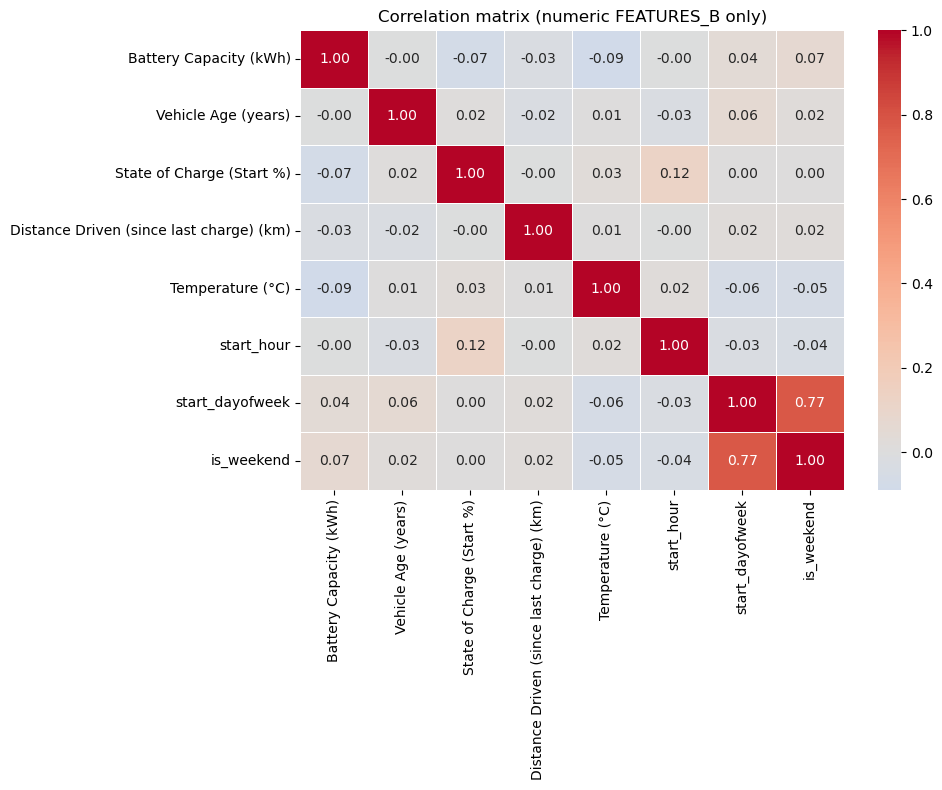

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation matrix (numeric FEATURES_B only)")
plt.tight_layout()
plt.show()


In [3]:
# Absolute correlations, ignore diagonal and duplicates (upper triangle only)
corr_abs = corr.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

# Show pairs above a threshold (tune this)
THRESH = 0.80
high_corr_pairs = (
    upper.stack()
         .sort_values(ascending=False)
         .loc[lambda s: s >= THRESH]
)

high_corr_pairs


Series([], dtype: float64)

ML: these are for cross-validation(repeated train/validation splits)
- Important: StratifiedKFold is for classification when you want each fold to keep similar class ratios (same % flexible / not flexible)
- But does not respect time order. If I care about time, i need to use TimeSeriesSplit instead.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate         # cross-validation (repeated train/validation splits)
from sklearn.compose import ColumnTransformer                   # applies diff preprocessing to diff columns
from sklearn.pipeline import Pipeline                           # chains steps together (preprocessing -> model)
from sklearn.preprocessing import OneHotEncoder, StandardScaler # turns categorical text into numbers 
from sklearn.impute import SimpleImputer                        # fills missing values 

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

y = df["is_flexible"].astype(int)

FEATURES_B =[
    "Battery Capacity (kWh)", "Vehicle Age (years)",
    "State of Charge (Start %)", "Distance Driven (since last charge) (km)", "Temperature (°C)",
    "Vehicle Model", "Charging Station Location", "Charger Type", "User Type",
    "start_hour", "start_dayofweek", "start_part_of_day"
]

X = df[FEATURES_B].copy()   #.copy() makes a separate copy so changes to X won’t accidentally alter df.

# Time-based train/test split (instead of random splitting)
df_sorted = df.sort_values("Charging Start Time").reset_index()
#reset_index() creates a new 0..N index and keeps the old index in a column called "index".
# That old "index" is used later to refer back to the original rows.
split = int(len(df_sorted) * 0.8)
train_idx = df_sorted.loc[:split-1, "index"]        #original indices of the first 80% (older sessions)
test_idx = df_sorted.loc[split:, "index"]           #original indices of the last 20 sessions (newer sessions)

x_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_test, y_test = X.loc[test_idx], y.loc[test_idx]

# Step 6: Separate numeric vs categorical columns

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# Step 7: Build preprocessing (cleaning) steps
preprocess = ColumnTransformer(
    
)

# Acknowledgements before continuing

So you should run two setups:

A (post-hoc explanation / sanity check): include durations → will look great but is partly cheating.

B (real prediction at plug-in time): only use features known when the user plugs in (this is the one that matters for smart-charging scenarios).

## Setup B (predict 'flexibilty' at plug-in time)
I use things only i know at start:
- time features: start_hour, day_of_week, is_weekend, month
- context: location, charger_type, user_type
- vehicle/session state: SOC_start, battery_capacity, maybe temperature

NOT including:
- delay_duration_h, session_duration_h, charge_duration_h, utilisation_rate 
- targets like Energy Consumed (kWh) (unless predicting after the fact)